# Scores, Kernels, and Optimal Transport

> *"Every divergence we have seen so far compares distributions by looking at their densities — the 'height' of the probability landscape. What if we compare the slopes instead?"*

In the preceding notebooks, we built a rich toolkit for comparing distributions:
- [Notebook 1](Divergence.ipynb): Shannon's information-theoretic measures (entropy, KL, MI)
- [Notebook 2](Beyond_KL.ipynb): f-divergences and Rényi families
- [Notebook 3](Distances_and_Testing.ipynb): Integral probability metrics (Wasserstein, energy, MMD)
- [Notebook 4](Dependence_and_Causality.ipynb): Multivariate dependence and causal information flow

This notebook ventures into the **modern frontier** of divergence measures, where three powerful mathematical traditions converge:

| Measure | Core idea | Tradition | Key advantage |
|---------|-----------|-----------|---------------|
| **Fisher Divergence** | Compare *slopes* of log-densities | Differential geometry | Works without normalizing constants |
| **Kernel Stein Discrepancy** | Stein's identity meets kernel methods | Functional analysis | Goodness-of-fit without computing $Z$ |
| **Sinkhorn Divergence** | Entropic regularization of optimal transport | Optimization theory | Makes OT fast and differentiable |

These measures have become essential tools in modern machine learning — powering score-matching models, MCMC diagnostics, and generative adversarial networks.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from divergence import (
    fisher_divergence,
    kernel_stein_discrepancy,
    sinkhorn_divergence,
    wasserstein_distance,
    energy_distance,
)

plt.rcParams.update({
    'figure.figsize': (8, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
})

np.random.seed(42)

from pathlib import Path
FIGURES_DIR = Path('figures/scores_and_transport')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

---

## 1. The Score Function: Fisher's Enduring Insight

### The man who shaped modern statistics

**Sir Ronald Aylmer Fisher** (1890–1962) is arguably the most influential statistician of the twentieth century. Working at Rothamsted Experimental Station in the English countryside — surrounded by agricultural field trials — he laid the foundations of modern statistical inference: maximum likelihood, sufficiency, analysis of variance, experimental design.

<!-- Portrait: R. A. Fisher (1890–1962) — Rothamsted, surrounded by wheat fields and mathematical insight -->

Among Fisher's many contributions, one concept stands out for its depth and elegance: the **score function**. For a probability density $p(x)$, the score is simply the gradient of the log-density:

$$
s_p(x) = \nabla_x \log p(x)
$$

Why is this important? Because the score captures the **local geometry** of the distribution — at each point, it tells you which direction increases probability the fastest. It is the "slope" of the log-density landscape.

For the standard normal $\mathcal{N}(0, 1)$, the score is delightfully simple:

$$
s(x) = \frac{d}{dx} \log\left(\frac{1}{\sqrt{2\pi}} e^{-x^2/2}\right) = -x
$$

At $x = 0$ (the peak), the score is zero — you're at the top. At $x = 2$, the score is $-2$ — the density is falling steeply to the right, pulling you back toward the center.

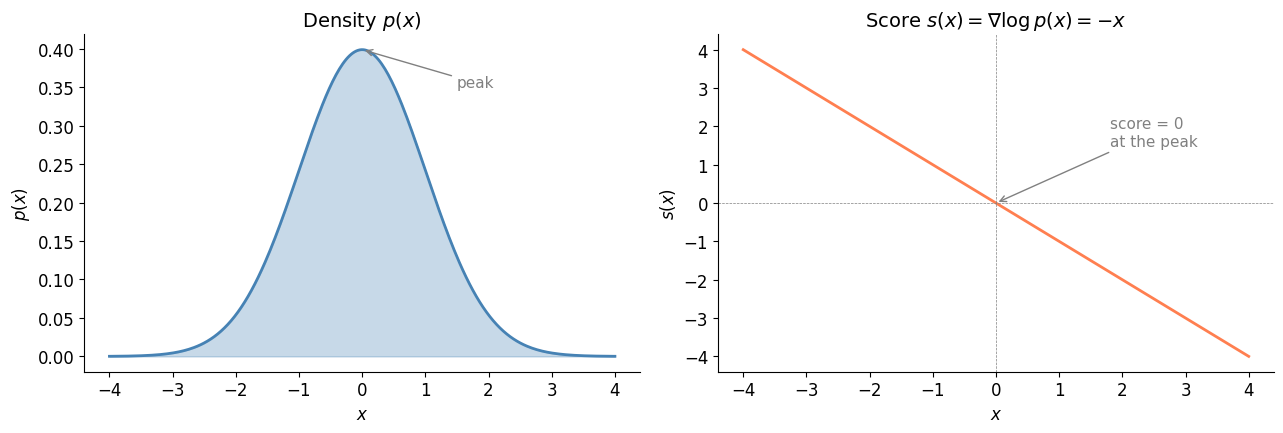

In [2]:
# Visualize the density and its score function side by side
x_grid = np.linspace(-4, 4, 300)
density = norm.pdf(x_grid)
score = -x_grid  # ∇ log p(x) = -x for N(0,1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Density
ax1.fill_between(x_grid, density, alpha=0.3, color='steelblue')
ax1.plot(x_grid, density, color='steelblue', lw=2)
ax1.set_title('Density $p(x)$', fontsize=14)
ax1.set_xlabel('$x$')
ax1.set_ylabel('$p(x)$')
ax1.annotate('peak', xy=(0, norm.pdf(0)), xytext=(1.5, 0.35),
             arrowprops=dict(arrowstyle='->', color='gray'),
             fontsize=11, color='gray')

# Score
ax2.plot(x_grid, score, color='coral', lw=2)
ax2.axhline(0, color='gray', lw=0.5, ls='--')
ax2.axvline(0, color='gray', lw=0.5, ls='--')
ax2.set_title('Score $s(x) = \\nabla \\log p(x) = -x$', fontsize=14)
ax2.set_xlabel('$x$')
ax2.set_ylabel('$s(x)$')
ax2.annotate('score = 0\nat the peak', xy=(0, 0), xytext=(1.8, 1.5),
             arrowprops=dict(arrowstyle='->', color='gray'),
             fontsize=11, color='gray')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'density_and_score.png', dpi=150, bbox_inches='tight')
plt.show()

The density tells you *how likely* each point is. The score tells you *which way probability increases fastest*. This shift in perspective — from heights to slopes — is the foundation of modern score-based methods.

---

## 2. Fisher Divergence: Comparing Slopes

The **Fisher divergence** between distributions $P$ and $Q$ measures how different their score functions are, *as experienced by points drawn from $P$*:

$$
D_F(P \| Q) = \mathbb{E}_{x \sim P}\!\left[\|\nabla \log p(x) - \nabla \log q(x)\|^2\right]
$$

This is the **expected squared difference between the slopes** of the two log-densities. If $P$ and $Q$ have the same shape (i.e., the same score function everywhere), the Fisher divergence is zero.

**A beautiful closed-form case:** For $P = \mathcal{N}(0, 1)$ and $Q = \mathcal{N}(\mu, 1)$ (same variance, different means), the Fisher divergence is exactly:

$$
D_F = \mathbb{E}_P[\|(-x) - (-(x - \mu))\|^2] = \mathbb{E}_P[\mu^2] = \mu^2
$$

Elegant! The Fisher divergence between two unit-variance normals is simply the squared distance between their means.

In [3]:
n = 5000
samples_p = np.random.randn(n)  # P = N(0, 1)

# Known score functions
def score_standard_normal(x):
    """Score of N(0, 1): s(x) = -x"""
    return -x

def score_shifted_normal(x, mu=2.0):
    """Score of N(mu, 1): s(x) = -(x - mu)"""
    return -(x - mu)

# Fisher divergence: P = Q → should be 0
fd_same = fisher_divergence(
    samples_p, score_standard_normal, score_p=score_standard_normal
)
print(f'D_F(N(0,1) || N(0,1)) = {fd_same:.4f}  (expected: 0.0)')

# Fisher divergence: P = N(0,1), Q = N(2,1) → should be μ² = 4.0
fd_shifted = fisher_divergence(
    samples_p,
    lambda x: score_shifted_normal(x, mu=2.0),
    score_p=score_standard_normal,
)
print(f'D_F(N(0,1) || N(2,1)) = {fd_shifted:.4f}  (expected: μ² = 4.0)')

D_F(N(0,1) || N(0,1)) = 0.0000  (expected: 0.0)
D_F(N(0,1) || N(2,1)) = 4.0000  (expected: μ² = 4.0)


### How Fisher divergence grows with separation

Let's sweep the mean shift $\mu$ and verify the $D_F = \mu^2$ relationship:

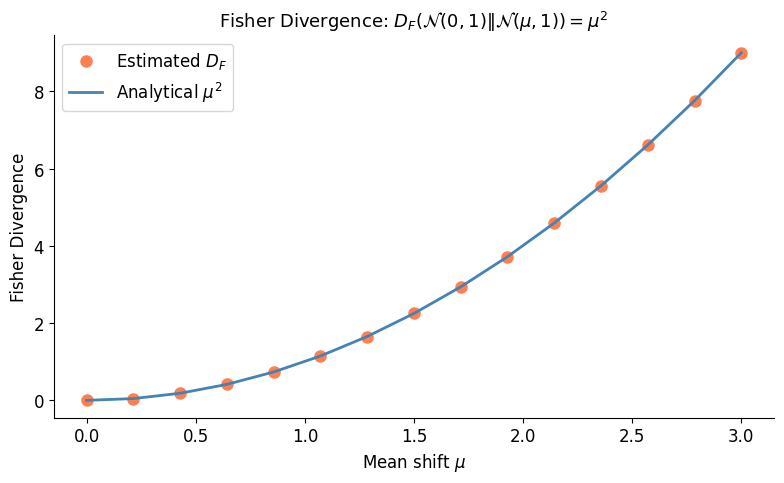

In [4]:
mu_values = np.linspace(0, 3, 15)
fd_values = []

for mu in mu_values:
    fd = fisher_divergence(
        samples_p,
        lambda x, m=mu: -(x - m),  # score of N(mu, 1)
        score_p=score_standard_normal,
    )
    fd_values.append(fd)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(mu_values, fd_values, 'o', color='coral', markersize=8, label='Estimated $D_F$')
ax.plot(mu_values, mu_values**2, '-', color='steelblue', lw=2, label='Analytical $\\mu^2$')
ax.set_xlabel('Mean shift $\\mu$')
ax.set_ylabel('Fisher Divergence')
ax.set_title('Fisher Divergence: $D_F(\\mathcal{N}(0,1) \\| \\mathcal{N}(\\mu,1)) = \\mu^2$',
             fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fisher_divergence_parabola.png', dpi=150, bbox_inches='tight')
plt.show()

The estimated values trace the analytical $\mu^2$ parabola almost perfectly. This is a hallmark of a well-behaved divergence: clean, interpretable, and efficiently estimable.

### When you don't know the score: estimation from data

In practice, we often don't have an analytical expression for $\nabla \log p$. The `fisher_divergence` function can **estimate** the score of $P$ from samples using a kernel density gradient estimator — trading some accuracy for generality:

In [5]:
# Estimate score of P from data (no analytical score_p provided)
fd_estimated = fisher_divergence(
    samples_p,
    lambda x: score_shifted_normal(x, mu=2.0),
    # score_p not specified → estimated via kernel density gradient
)
print(f'D_F with estimated score_p: {fd_estimated:.4f}')
print(f'D_F with known score_p:     {fd_shifted:.4f}')
print(f'Analytical value:           4.0000')
print(f'\nScore estimation introduces some noise, but the order of magnitude is right.')

D_F with estimated score_p: 4.1912
D_F with known score_p:     4.0000
Analytical value:           4.0000

Score estimation introduces some noise, but the order of magnitude is right.


### Why Fisher divergence matters today

The Fisher divergence has become a cornerstone of modern generative modeling:

- **Score matching** (Hyvärinen, 2005): Train a model by minimizing the Fisher divergence between data and model — crucially, this *doesn't require computing the normalizing constant* of the model.
- **Diffusion models** (Song & Ermon, 2019): The explosion of diffusion-based image generation (Stable Diffusion, DALL-E 3) is built on score matching — estimating the score function at different noise levels.
- **Stein variational inference** (Liu & Wang, 2016): Uses score functions to transport particles toward the posterior.

Fisher's original insight about the importance of log-likelihood gradients, conceived amid English wheat fields in the 1920s, now powers the most impressive generative AI systems in the world.

---

## 3. Kernel Stein Discrepancy: Testing Without the Normalizing Constant

### The problem that plagued Bayesian statistics

Here is one of the deepest practical problems in statistics: you have samples (say, from an MCMC sampler) and you want to test whether they actually come from a target distribution $P$. But computing $P$'s density requires evaluating a **normalizing constant** $Z = \int \exp(-U(x))\,dx$ that is often intractable.

This is the situation in Bayesian inference, where $P$ is the posterior distribution and $Z$ is the marginal likelihood — the integral that makes Bayesian computation so challenging.

### Stein's identity: a mathematical miracle

In 1972, **Charles Stein** at Stanford discovered a remarkable identity: for any smooth function $h$ and distribution $P$ with score $s_p$,

$$
\mathbb{E}_{x \sim P}\bigl[s_p(x)\,h(x) + \nabla h(x)\bigr] = 0
$$

<!-- Portrait: Charles Stein (1920–2016) — Stanford, the master of unexpected identities -->

This identity holds for *any* test function $h$ — it characterizes the distribution $P$ completely. And it depends on $P$ only through the **score function**, which doesn't require the normalizing constant!

### From Stein's identity to a practical test

In 2016, **Qiang Liu**, **Jason Lee**, and **Michael Jordan** at UC Berkeley combined Stein's identity with **kernel methods** to create the **kernel Stein discrepancy (KSD)** — a practical, computable measure of how well samples approximate a target distribution.

The KSD uses a **Stein kernel**:

$$
u_p(x, y) = s_p(x)^\top s_p(y)\,k(x,y) + s_p(x)^\top \nabla_y k(x,y) + s_p(y)^\top \nabla_x k(x,y) + \nabla_x \cdot \nabla_y k(x,y)
$$

where $k$ is an RBF kernel. The squared KSD is estimated via a U-statistic:

$$
\widehat{\mathrm{KSD}}^2 = \frac{1}{n(n-1)} \sum_{i \neq j} u_p(x_i, x_j)
$$

**The key insight**: $\mathrm{KSD}(Q, P) = 0$ if and only if $Q = P$. And computing it requires only the **score function** of $P$ — not the normalizing constant.

In [6]:
n = 2000

# Case 1: Samples actually from N(0,1) → KSD should be ≈ 0
samples_correct = np.random.randn(n)
ksd_correct = kernel_stein_discrepancy(samples_correct, score_standard_normal)

# Case 2: Samples from N(2,1) tested against N(0,1) → KSD should be large
samples_wrong = np.random.normal(2.0, 1.0, n)
ksd_wrong = kernel_stein_discrepancy(samples_wrong, score_standard_normal)

print('Kernel Stein Discrepancy (testing against N(0,1) score):')
print(f'  Samples from N(0,1): KSD² = {ksd_correct:.6f}  ← close to zero ✓')
print(f'  Samples from N(2,1): KSD² = {ksd_wrong:.6f}  ← clearly positive ✗')

Kernel Stein Discrepancy (testing against N(0,1) score):
  Samples from N(0,1): KSD² = 0.001471  ← close to zero ✓
  Samples from N(2,1): KSD² = 2.272547  ← clearly positive ✗


### How KSD grows with mismatch

Let's visualize how the KSD responds as we shift the sample distribution further from the target:

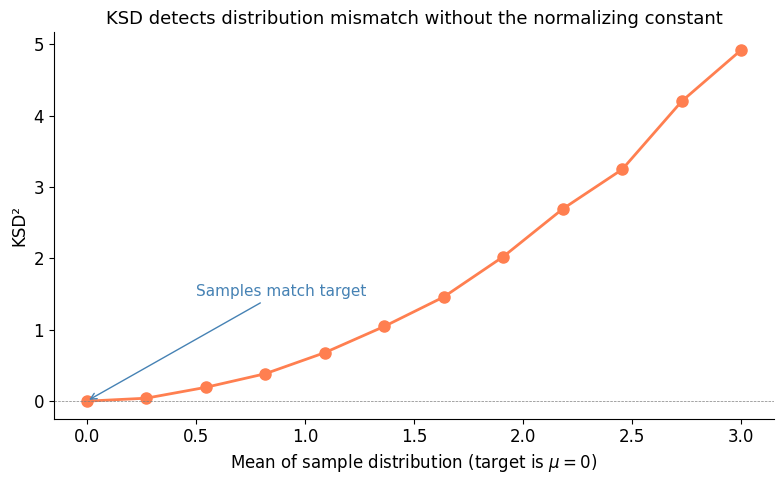

In [7]:
mu_shifts = np.linspace(0, 3, 12)
ksd_values = []

for mu in mu_shifts:
    samples_shifted = np.random.normal(mu, 1.0, n)
    ksd = kernel_stein_discrepancy(samples_shifted, score_standard_normal)
    ksd_values.append(ksd)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(mu_shifts, ksd_values, 'o-', color='coral', markersize=8, lw=2)
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.set_xlabel('Mean of sample distribution (target is $\\mu = 0$)')
ax.set_ylabel('KSD²')
ax.set_title('KSD detects distribution mismatch without the normalizing constant',
             fontsize=13)
ax.annotate('Samples match target', xy=(0, ksd_values[0]),
            xytext=(0.5, max(ksd_values)*0.3),
            arrowprops=dict(arrowstyle='->', color='steelblue'),
            fontsize=11, color='steelblue')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ksd_vs_mismatch.png', dpi=150, bbox_inches='tight')
plt.show()

The KSD is essentially zero when the samples match the target, then rises steeply as the mismatch grows. This makes it an excellent **diagnostic tool** for MCMC convergence: if your KSD is small, your sampler has found the right distribution.

### Two dimensions: the same principle scales

In [8]:
# 2D standard normal
samples_2d_correct = np.random.randn(n, 2)
samples_2d_wrong = np.random.normal(1.5, 1.0, (n, 2))

ksd_2d_correct = kernel_stein_discrepancy(samples_2d_correct, score_standard_normal)
ksd_2d_wrong = kernel_stein_discrepancy(samples_2d_wrong, score_standard_normal)

print('2D KSD (testing against N(0, I₂) score):')
print(f'  Correct samples: KSD² = {ksd_2d_correct:.6f}')
print(f'  Wrong samples:   KSD² = {ksd_2d_wrong:.6f}')

2D KSD (testing against N(0, I₂) score):
  Correct samples: KSD² = 0.000412
  Wrong samples:   KSD² = 2.659863


---

## 4. Sinkhorn Divergence: Making Optimal Transport Practical

### The old dream of moving earth

In 1781, the French mathematician **Gaspard Monge** posed a seemingly simple question: given a pile of sand and a hole to fill, what is the cheapest way to move the sand? Two centuries later, this question — formalized as **optimal transport** — has become one of the most active areas of applied mathematics.

We encountered the Wasserstein distance in [Notebook 3](Distances_and_Testing.ipynb), where **Leonid Kantorovich** (1942) showed how to solve Monge's problem using linear programming. But there's a catch: computing the exact Wasserstein distance requires solving a linear program of size $n \times m$, which becomes prohibitively expensive for large datasets.

### Cuturi's breakthrough: entropy to the rescue

In 2013, **Marco Cuturi** — an Italian-French researcher working in Kyoto — had an idea that transformed the field. What if we add a small **entropic regularization** term to the transport problem?

<!-- Portrait: Marco Cuturi — bridging optimal transport and machine learning in Kyoto -->

Instead of minimizing just the transport cost $\langle T, C \rangle$, we minimize:

$$
\mathrm{OT}_\varepsilon(P, Q) = \min_{T \in \Pi(P, Q)} \left\{\langle T, C \rangle - \varepsilon\, H(T)\right\}
$$

where $H(T) = -\sum_{ij} T_{ij} \log T_{ij}$ is the entropy of the transport plan. This tiny modification has profound consequences:

1. The solution can be found by **matrix scaling** (the Sinkhorn-Knopp algorithm, 1967) — much faster than linear programming
2. The resulting distance is **differentiable** — enabling gradient-based optimization
3. The computation is **GPU-friendly** — just matrix multiplications

### The debiasing trick

There's one problem: $\mathrm{OT}_\varepsilon(P, P) \neq 0$ — the entropic regularization introduces a bias. In 2018, **Aude Genevay**, **Gabriel Peyré**, and **Marco Cuturi** proposed a simple fix: **subtract the self-transport costs**:

$$
S_\varepsilon(P, Q) = \mathrm{OT}_\varepsilon(P, Q) - \frac{1}{2}\bigl(\mathrm{OT}_\varepsilon(P, P) + \mathrm{OT}_\varepsilon(Q, Q)\bigr)
$$

This **debiased Sinkhorn divergence** satisfies $S_\varepsilon(P, P) = 0$ and inherits all the computational advantages of the regularized problem.

In [9]:
n = 500

P = np.random.randn(n)
Q_close = np.random.normal(0.5, 1.0, n)
Q_far = np.random.normal(2.0, 1.0, n)

# Identity property: S(P, P) = 0
s_pp = sinkhorn_divergence(P, P, epsilon=0.1)
print(f'S_ε(P, P) = {s_pp:.6f}  (expected: 0.0 — debiasing works!)')

# Divergence grows with distance
s_close = sinkhorn_divergence(P, Q_close, epsilon=0.1)
s_far = sinkhorn_divergence(P, Q_far, epsilon=0.1)
print(f'\nS_ε(P, Q_close)  = {s_close:.4f}  (μ = 0.5)')
print(f'S_ε(P, Q_far)    = {s_far:.4f}  (μ = 2.0)')
print(f'Farther distributions → larger divergence.')

S_ε(P, P) = 0.000000  (expected: 0.0 — debiasing works!)



S_ε(P, Q_close)  = 0.3020  (μ = 0.5)
S_ε(P, Q_far)    = 4.0060  (μ = 2.0)
Farther distributions → larger divergence.


In [10]:
# Symmetry check
s_pq = sinkhorn_divergence(P, Q_far, epsilon=0.1)
s_qp = sinkhorn_divergence(Q_far, P, epsilon=0.1)
print(f'S_ε(P, Q) = {s_pq:.4f}')
print(f'S_ε(Q, P) = {s_qp:.4f}')
print(f'Symmetric? {np.isclose(s_pq, s_qp, rtol=0.05)}')

S_ε(P, Q) = 4.0060
S_ε(Q, P) = 4.0072
Symmetric? True


### The Sinkhorn divergence as a function of separation

Let's see how the Sinkhorn divergence compares to the Wasserstein distance and energy distance as we shift the sample distribution:

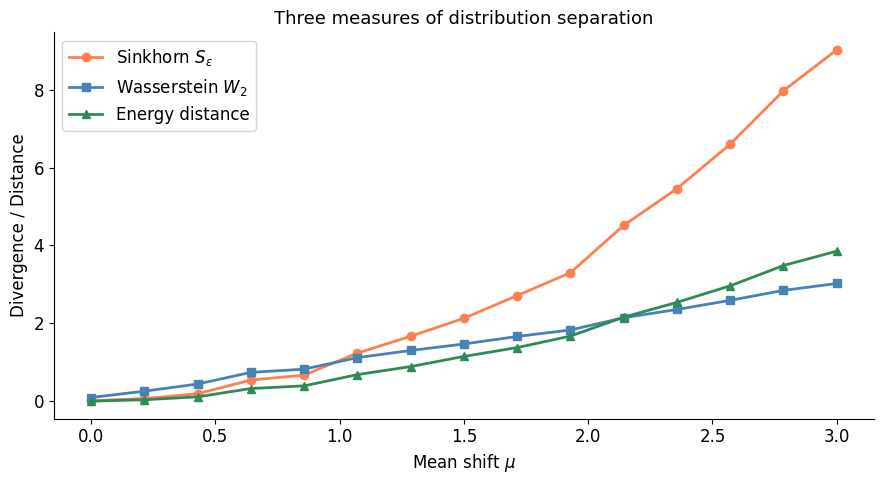

In [11]:
mu_range = np.linspace(0, 3, 15)
sinkhorn_vals = []
wasserstein_vals = []
energy_vals = []

for mu in mu_range:
    Q_shifted = np.random.normal(mu, 1.0, n)
    sinkhorn_vals.append(sinkhorn_divergence(P, Q_shifted, epsilon=0.1))
    wasserstein_vals.append(wasserstein_distance(P, Q_shifted, p=2))
    energy_vals.append(energy_distance(P, Q_shifted))

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(mu_range, sinkhorn_vals, 'o-', color='coral', markersize=6, lw=2,
        label='Sinkhorn $S_\\varepsilon$')
ax.plot(mu_range, wasserstein_vals, 's-', color='steelblue', markersize=6, lw=2,
        label='Wasserstein $W_2$')
ax.plot(mu_range, energy_vals, '^-', color='seagreen', markersize=6, lw=2,
        label='Energy distance')

ax.set_xlabel('Mean shift $\\mu$')
ax.set_ylabel('Divergence / Distance')
ax.set_title('Three measures of distribution separation', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sinkhorn_vs_wasserstein_energy.png', dpi=150, bbox_inches='tight')
plt.show()

All three measures increase monotonically with the mean shift, but they have different sensitivities and growth rates. The Sinkhorn divergence provides a smooth, differentiable alternative to the Wasserstein distance — and because it only requires matrix multiplications, it can be computed orders of magnitude faster for large datasets.

### The regularization parameter $\varepsilon$

The parameter $\varepsilon$ controls the trade-off between approximation quality and computational efficiency:
- **Small $\varepsilon$**: The Sinkhorn divergence approaches the true Wasserstein distance, but convergence is slower.
- **Large $\varepsilon$**: More regularization makes the algorithm faster but the divergence becomes smoother and less sharp.

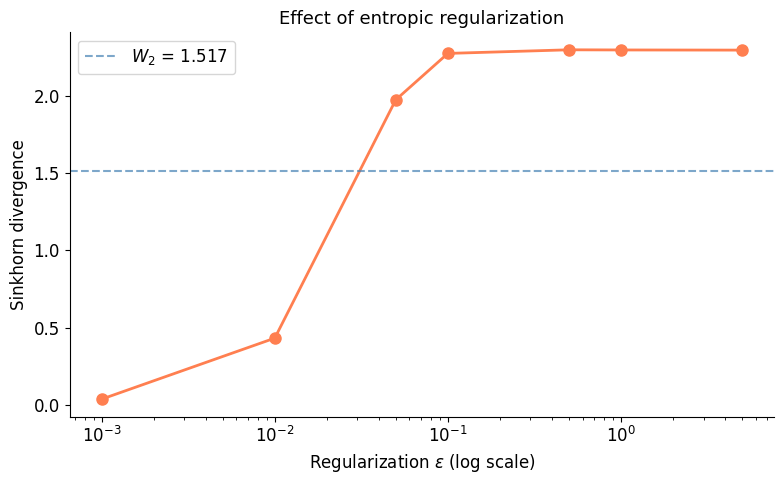

In [12]:
epsilons = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0]
P_demo = np.random.randn(300)
Q_demo = np.random.normal(1.5, 1.0, 300)

sink_eps = [sinkhorn_divergence(P_demo, Q_demo, epsilon=eps) for eps in epsilons]

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(epsilons, sink_eps, 'o-', color='coral', markersize=8, lw=2)
ax.set_xlabel('Regularization $\\varepsilon$ (log scale)')
ax.set_ylabel('Sinkhorn divergence')
ax.set_title('Effect of entropic regularization', fontsize=13)

# Reference: Wasserstein W2
w2_ref = wasserstein_distance(P_demo, Q_demo, p=2)
ax.axhline(w2_ref, color='steelblue', ls='--', lw=1.5, alpha=0.7,
           label=f'$W_2$ = {w2_ref:.3f}')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sinkhorn_epsilon_effect.png', dpi=150, bbox_inches='tight')
plt.show()

### Higher dimensions: where Sinkhorn shines

In [13]:
# 2D point clouds
P_2d = np.random.randn(n, 2)
Q_2d = np.random.normal(1.0, 1.0, (n, 2))

s_2d = sinkhorn_divergence(P_2d, Q_2d, epsilon=0.5)
s_2d_self = sinkhorn_divergence(P_2d, P_2d, epsilon=0.5)

print(f'2D Sinkhorn divergence (different): {s_2d:.4f}')
print(f'2D Sinkhorn divergence (same):      {s_2d_self:.6f}  (≈ 0)')

2D Sinkhorn divergence (different): 2.0452
2D Sinkhorn divergence (same):      0.000000  (≈ 0)


### Applications

The Sinkhorn divergence has become a workhorse in modern machine learning:

- **Generative modeling**: Training Wasserstein GANs with the Sinkhorn loss instead of the Kantorovich dual
- **Domain adaptation**: Aligning feature distributions across different data sources
- **Single-cell genomics**: Comparing cell-type distributions across experimental conditions
- **Computer graphics**: Shape matching and texture interpolation
- **Fairness**: Measuring and mitigating distributional disparities between groups

---

## Summary: The Modern Landscape

We have explored three fundamentally different approaches to comparing distributions:

| Measure | Compares | Key advantage | Computational cost |
|---------|----------|---------------|-----|
| **Fisher Divergence** | Score functions (slopes) | No normalizing constant needed | $O(n)$ with known scores |
| **Kernel Stein Discrepancy** | Samples vs. score function | Goodness-of-fit without $Z$ | $O(n^2)$ (kernel matrix) |
| **Sinkhorn Divergence** | Sample clouds via transport | Fast, differentiable OT | $O(n^2 \cdot \text{iterations})$ |

These measures represent three of the most active research frontiers in computational statistics and machine learning. They illustrate how ideas from very different mathematical traditions — Fisher's score functions (1920s), Stein's characterization of distributions (1970s), Kantorovich's optimal transport (1940s), and Cuturi's entropic regularization (2013) — can be combined into practical tools that power today's most advanced AI systems.

---

## The Divergence Notebook Series

| # | Notebook | What it covers |
|---|----------|---------------|
| 1 | [Divergence](Divergence.ipynb) | Shannon's foundations: entropy, cross entropy, KL divergence, Jensen-Shannon, mutual information, joint and conditional entropy |
| 2 | [Beyond KL](Beyond_KL.ipynb) | f-divergences (TV, Hellinger, chi-squared, Jeffreys, Cressie-Read) and the Rényi family |
| 3 | [Distances and Testing](Distances_and_Testing.ipynb) | Sample-based methods: Wasserstein, energy distance, MMD, kNN estimators, two-sample permutation tests |
| 4 | [Dependence and Causality](Dependence_and_Causality.ipynb) | Multivariate dependence (TC, NMI, VI) and directed information flow (transfer entropy) |
| 5 | **Scores and Transport** *(this notebook)* | The modern frontier: Fisher divergence, kernel Stein discrepancy, Sinkhorn divergence |
| 6 | [Bayesian Diagnostics](Bayesian_Diagnostics.ipynb) | End-to-end MCMC with emcee: convergence diagnostics, information gain, Bayesian surprise |
| 7 | [Real-World Applications](Real_World_Applications.ipynb) | Stock market contagion, crop yields, Phillips Curve — real data, real stakes |